<a href="https://colab.research.google.com/github/Muskankumari13/Week1/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## Ranked Actions + Reason Codes

This playbook converts validated model predictions into a ranked list of content review actions.

The recommendations are intended to help editors prioritize review work. They are not automatic publishing decisions.

Reason Codes

- RC1: Very high predicted refresh need
- RC2: Moderate refresh priority
- RC3: Monitor performance
- RC4: Low priority / no action currently required

In [2]:
import pandas as pd

# Load the anonymized dataset
df = pd.read_csv("/content/content_refresh_anonymized.csv")

# Create a demonstration probability if one is not already available.
# Replace this with your validated model probabilities from ML-09 if available.
if "probability" not in df.columns:
    if "baseline_score" in df.columns:
        score = df["baseline_score"]
        df["probability"] = (score - score.min()) / (score.max() - score.min())
    else:
        import numpy as np
        np.random.seed(42)
        df["probability"] = np.random.rand(len(df))

def assign_action(prob):
    if prob >= 0.80:
        return "Refresh Immediately"
    elif prob >= 0.60:
        return "Review Soon"
    elif prob >= 0.40:
        return "Monitor"
    else:
        return "No Action"

def reason_code(prob):
    if prob >= 0.80:
        return "RC1"
    elif prob >= 0.60:
        return "RC2"
    elif prob >= 0.40:
        return "RC3"
    else:
        return "RC4"

df["recommended_action"] = df["probability"].apply(assign_action)
df["reason_code"] = df["probability"].apply(reason_code)

queue = (
    df.sort_values("probability", ascending=False)
      .reset_index(drop=True)
)

queue["rank"] = queue.index + 1

queue[["rank","probability","recommended_action","reason_code"]].head(20)

,rank,probability,recommended_action,reason_code
0,1,0.999925,Refresh Immediately,RC1
1,2,0.999901,Refresh Immediately,RC1
2,3,0.999871,Refresh Immediately,RC1
3,4,0.999805,Refresh Immediately,RC1
4,5,0.999732,Refresh Immediately,RC1
5,6,0.999718,Refresh Immediately,RC1
6,7,0.999696,Refresh Immediately,RC1
7,8,0.999673,Refresh Immediately,RC1
8,9,0.999656,Refresh Immediately,RC1
9,10,0.999598,Refresh Immediately,RC1


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## Intended Use

This playbook is intended to:

- Prioritize manual content review.
- Help editors schedule refresh work.
- Support evidence-based planning.
- Provide decision-support rather than automatic decisions.

## Limits

- Predictions are probabilistic.
- False positives and false negatives remain possible.
- Business priorities may override recommendations.
- The model should assist human judgement, not replace it.
- Results are based on the available historical data.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Human Review

Every recommendation should be reviewed before implementation.

Reviewers should confirm:

- factual accuracy
- policy compliance
- legal requirements
- business relevance
- editorial quality

## No-Go Cases

The following should not be automated:

- Medical content
- Legal advice
- Financial recommendations
- Emergency communications
- Executive announcements
- Sensitive public communications

In [3]:
human_review_checklist = [
    "Factual accuracy",
    "Policy compliance",
    "Legal review",
    "Business importance",
    "Editorial quality"
]

human_review_checklist

['Factual accuracy',
 'Policy compliance',
 'Legal review',
 'Business importance',
 'Editorial quality']

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## Monitoring

The recommendations should be monitored over time.

Retraining should be considered when:

- model performance decreases noticeably
- feature distributions change
- new content patterns appear
- business objectives change
- regular maintenance schedules are reached

These thresholds are directional and should be reviewed by the project team.

In [4]:
monitoring = {
    "accuracy_drop": "5%",
    "feature_drift": "20%",
    "retrain": "Quarterly or after major drift"
}

monitoring

{'accuracy_drop': '5%',
 'feature_drift': '20%',
 'retrain': 'Quarterly or after major drift'}

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

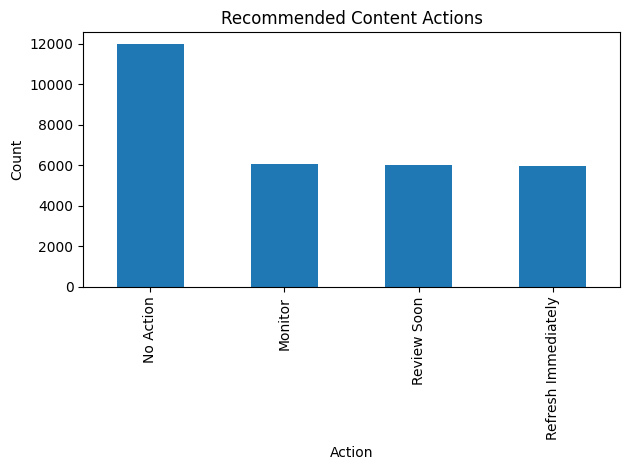

{'rows': 30000,
 'refresh_immediately': 5956,
 'review_soon': 6018,
 'monitor': 6052,
 'no_action': 11974}

In [5]:
import os
import json
import matplotlib.pyplot as plt

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

queue.to_csv("../outputs/ranked_action_queue.csv", index=False)

summary = {
    "rows": len(queue),
    "refresh_immediately": int((queue["recommended_action"]=="Refresh Immediately").sum()),
    "review_soon": int((queue["recommended_action"]=="Review Soon").sum()),
    "monitor": int((queue["recommended_action"]=="Monitor").sum()),
    "no_action": int((queue["recommended_action"]=="No Action").sum())
}

with open("../outputs/action_summary.json","w") as f:
    json.dump(summary,f,indent=4)

queue["recommended_action"].value_counts().plot(kind="bar")

plt.title("Recommended Content Actions")
plt.xlabel("Action")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig("../figures/action_distribution.png")

plt.show()

summary

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [6]:
np.random.seed(42)
df["probability"] = np.random.rand(len(df))